In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gwinc
import squeezingFC
from gwinc.ifo.noises import ifo_power
from gwinc.ifo.noises import arm_cavity

(5e-26, 1e-22)

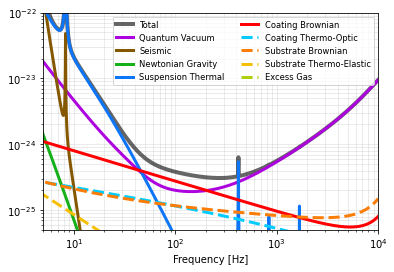

In [2]:
freqHF = np.logspace(0,4,3000)
budgetHF = gwinc.load_budget('ETHF',freq=freqHF)

# Example of adjustable parameters
#budgetHF.ifo.Infrastructure.Length=10000
#budgetHF.ifo.Optics.Curvature.ITM.Curvature=5070
#budgetHF.ifo.Optics.Curvature.ETM.Curvature=5070
#budgetHF.ifo.Materials.Substrate.Temp=290
#budgetHF.ifo.Squeezer.AmplitudedB=0

budgetHF.ifo.Squeezer.FilterCavity=squeezingFC.computeFCParams(budgetHF.ifo)
tracesHF = budgetHF.run()
fig = gwinc.plot_budget(tracesHF)
plt.xlim(5,10000)
plt.ylim([5*10**(-26), 1*10**(-22)])

In [3]:
arm_cavity(budgetHF.ifo).wBeam_ITM

0.12046693153452932

In [4]:
ifo_power(budgetHF.ifo).parm

3091467.7046071757

(5e-26, 1e-22)

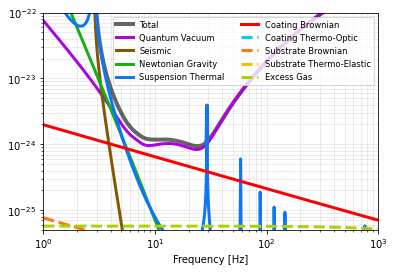

In [5]:
freqLF = np.logspace(0,3,3000)
budgetLF = gwinc.load_budget('ETLF',freq=freqLF)

# Example of adjustable parameters
#budgetLF.ifo.Infrastructure.Length=10000
#budgetLF.ifo.Optics.Curvature.ITM.Curvature=5070
#budgetLF.ifo.Optics.Curvature.ETM.Curvature=5070
#budgetLF.ifo.Materials.Substrate.Temp=290
#budgetLF.ifo.Squeezer.AmplitudedB=0


budgetHF.ifo.Squeezer.FilterCavity=squeezingFC.computeFCsParams(budgetLF.ifo,budgetLF.ifo.Squeezer.FilterCavity)
tracesLF = budgetLF.run()
fig = gwinc.plot_budget(tracesLF)
plt.xlim([1,1000])
plt.ylim([5*10**(-26), 1*10**(-22)])